In [1]:
import os
import torch
import matplotlib.pyplot as plt

from src.concaves.log import LogConcave

from src.diffeomorphisms.composition import CompositionDiffeomorphism
from src.diffeomorphisms.vector.starflow import StarFlowVectorDiffeomorphism
from src.diffeomorphisms.vector.concave import ConcaveVectorDiffeomorphism
from src.diffeomorphisms.vector.transform import TransformVectorDiffeomorphism

from src.distributions.starflows.r2.river_cross import RiverCrossStarFlowDistribution

from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.manifolds.isometrized_euclidean.vector import l2IsometrizedVectorEuclidean

from src.nn.module.riemannian.archetypal_mapping import RiemannianArchetypalMapping

# results folder
results_folder = os.path.join("results", "river_cross")
os.makedirs(results_folder, exist_ok=True)

# set random seed
torch.manual_seed(31)

Using NumPy backend


In [2]:
star_flow = RiverCrossStarFlowDistribution()

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


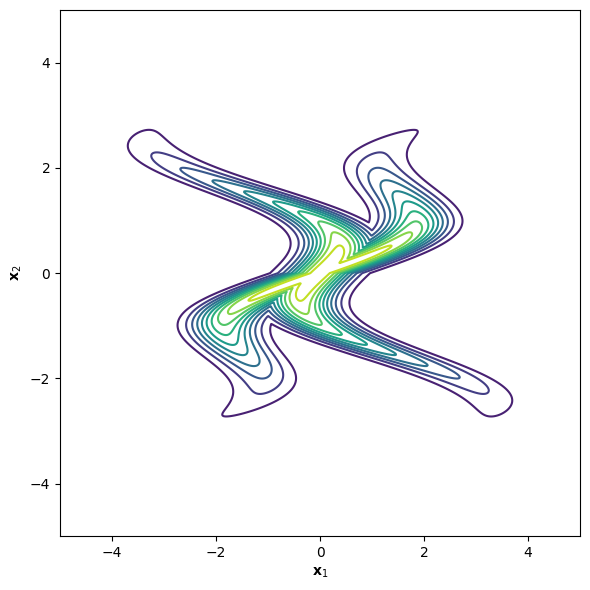

In [3]:
n_points = 1001
x = torch.linspace(-7, 7, n_points)
y = torch.linspace(-7, 7, n_points)
X, Y = torch.meshgrid(x, y)
XY = torch.stack([X.flatten(), Y.flatten()], dim=-1)
log_probs_multi = torch.exp(star_flow.log_prob(XY).reshape(n_points, n_points).detach())


# plot samples
plt.figure(figsize=(6, 6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis')
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "log_probs.png"))
plt.show()

In [4]:
phi_chi = StarFlowVectorDiffeomorphism(2, star_flow)
psi = ConcaveVectorDiffeomorphism(2, LogConcave(a=10.))
Omega = CompositionDiffeomorphism([phi_chi, psi])

# pullback manifolds
phi_chi_manifold = StandardPullbackVectorEuclidean(phi_chi)
Omega_manifold = StandardPullbackVectorEuclidean(Omega)

# iso pullback manifolds
iso_phi_chi_manifold = l2IsometrizedVectorEuclidean(phi_chi_manifold)
iso_Omega_manifold = l2IsometrizedVectorEuclidean(Omega_manifold)

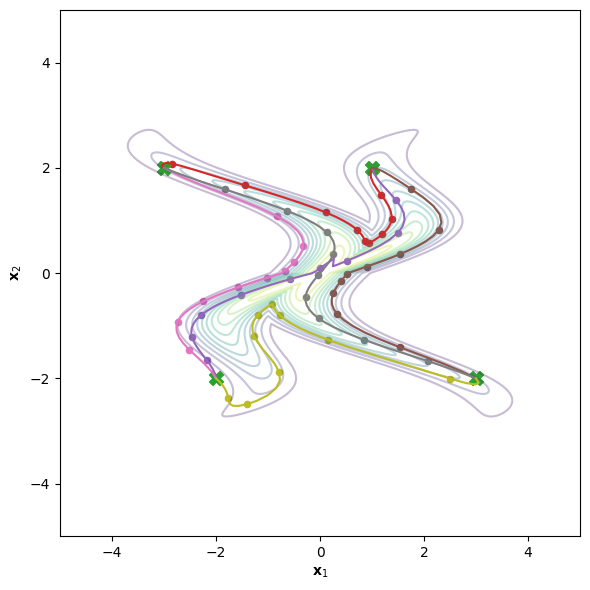

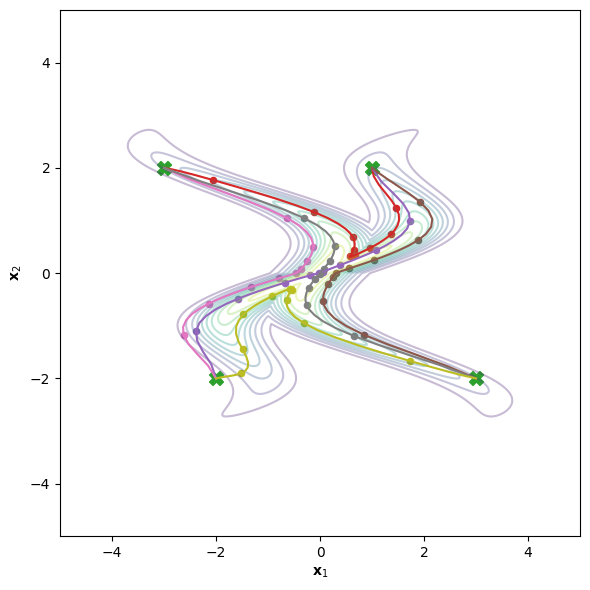

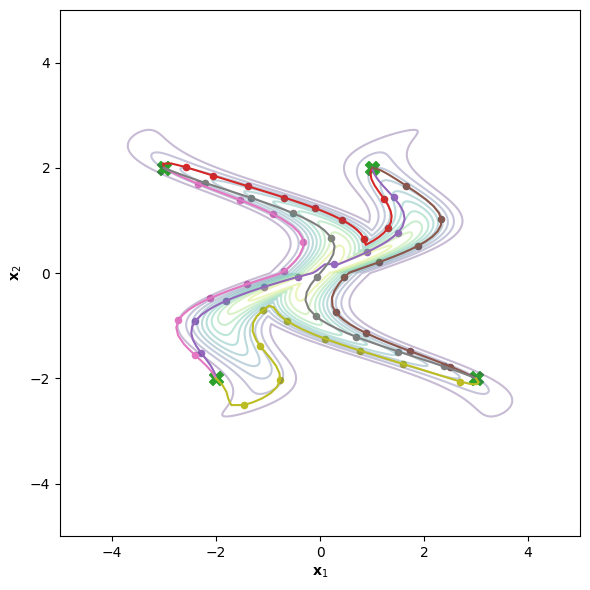

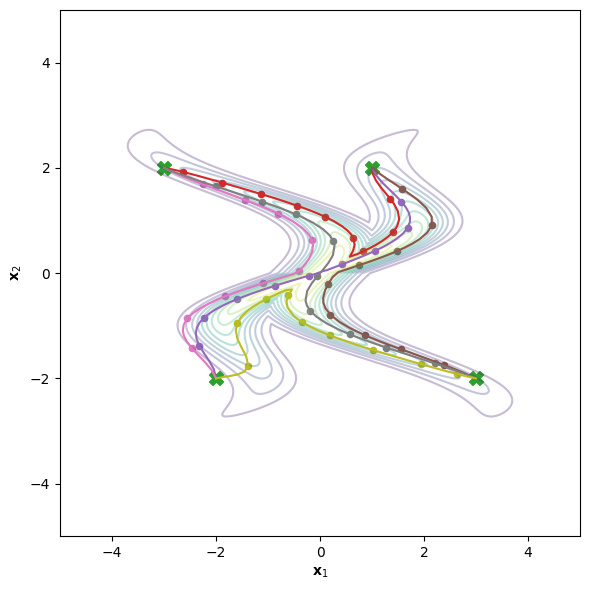

In [5]:
t = torch.linspace(0, 1, 50)
T = 5
archetypes = torch.tensor([[1., 2.], [-3., 2.], [-2., -2.], [3., -2.]])

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

k=3
for i in range(4):
    for j in range(i+1, 4):
        x_i = archetypes[i]
        x_j = archetypes[j]
        # interpolate between cluster centers
        phi_chi_geodesics = phi_chi_manifold.geodesic(x_i[None,None], x_j[None,None], t)[0,0,0]
        plt.plot(phi_chi_geodesics[:, 0].numpy(), phi_chi_geodesics[:, 1].numpy(), color=plt.cm.tab10(k))
        plt.scatter(phi_chi_geodesics[::T, 0].numpy(), phi_chi_geodesics[::T, 1].numpy(), color=plt.cm.tab10(k), marker='o', s=20)
        k += 1

plt.scatter(archetypes[:, 0].numpy(), archetypes[:, 1].numpy(), color=plt.cm.tab10(2), marker='X', s=100)
    
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics.png"))
plt.show()

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

k=3
for i in range(4):
    for j in range(i+1, 4):
        mu_i = archetypes[i]
        mu_j = archetypes[j]
        # interpolate between cluster centers
        Omega_geodesics = Omega_manifold.geodesic(mu_i[None,None], mu_j[None,None], t)[0,0,0]
        plt.plot(Omega_geodesics[:, 0].numpy(), Omega_geodesics[:, 1].numpy(), color=plt.cm.tab10(k))
        plt.scatter(Omega_geodesics[::T, 0].numpy(), Omega_geodesics[::T, 1].numpy(), color=plt.cm.tab10(k), marker='o', s=20)
        k += 1

plt.scatter(archetypes[:, 0].numpy(), archetypes[:, 1].numpy(), color=plt.cm.tab10(2), marker='X', s=100)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics_conv.png"))
plt.show()

# iso pullback manifolds
plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

k=3
for i in range(4):
    for j in range(i+1, 4):
        x_i = archetypes[i]
        x_j = archetypes[j]
        # interpolate between cluster centers
        phi_chi_geodesics = iso_phi_chi_manifold.geodesic(x_i[None,None], x_j[None,None], t)[0,0,0]
        plt.plot(phi_chi_geodesics[:, 0].numpy(), phi_chi_geodesics[:, 1].numpy(), color=plt.cm.tab10(k))
        plt.scatter(phi_chi_geodesics[::T, 0].numpy(), phi_chi_geodesics[::T, 1].numpy(), color=plt.cm.tab10(k), marker='o', s=20)  
        k += 1

plt.scatter(archetypes[:, 0].numpy(), archetypes[:, 1].numpy(), color=plt.cm.tab10(2), marker='X', s=100)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics_iso.png"))
plt.show()

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

k=3
for i in range(4):
    for j in range(i+1, 4):
        mu_i = archetypes[i]
        mu_j = archetypes[j]
        # interpolate between cluster centers
        Omega_geodesics = iso_Omega_manifold.geodesic(mu_i[None,None], mu_j[None,None], t)[0,0,0]
        plt.plot(Omega_geodesics[:, 0].numpy(), Omega_geodesics[:, 1].numpy(), color=plt.cm.tab10(k))
        plt.scatter(Omega_geodesics[::T, 0].numpy(), Omega_geodesics[::T, 1].numpy(), color=plt.cm.tab10(k), marker='o', s=20)
        k += 1

plt.scatter(archetypes[:, 0].numpy(), archetypes[:, 1].numpy(), color=plt.cm.tab10(2), marker='X', s=100)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "geodesics_conv_iso.png"))
plt.show()

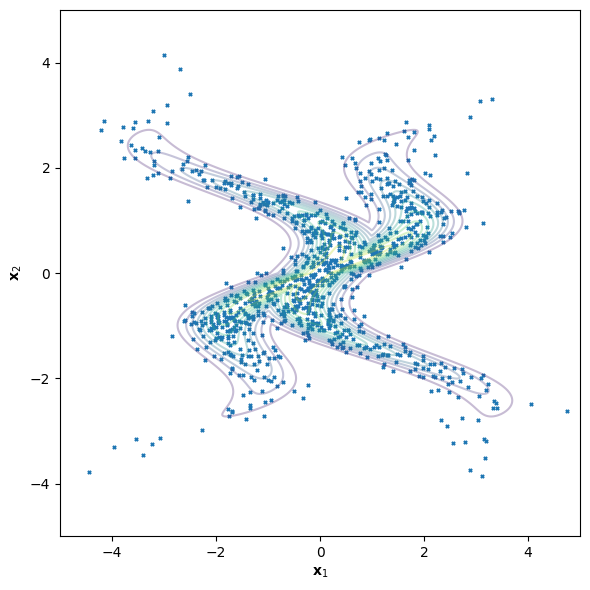

In [6]:
data = star_flow.sample(1000)

# plot samples
plt.figure(figsize=(6, 6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)
plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), color=plt.cm.tab10(0), marker='x', s=5)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "samples_starflow.png"))
plt.show()

In [7]:
# construct RAM
ram = RiemannianArchetypalMapping(Omega_manifold, archetypes)

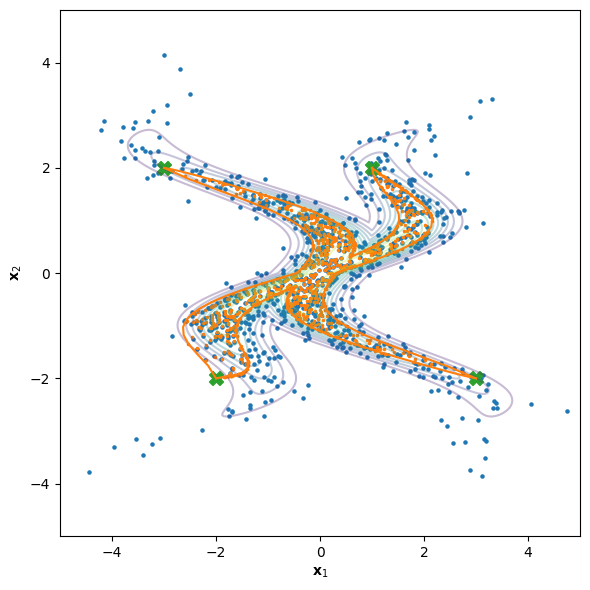

In [8]:
with torch.no_grad():
    # project data
    projected_data = ram.forward(data)

    # compute enclosing geodesics
    geodesics = torch.zeros(4, 50, 2)
    t = torch.linspace(0, 1, 50)
    for i in range(4):
        geodesics[i] = Omega_manifold.geodesic(archetypes[i][None,None], archetypes[(i+1)%4][None,None], t)[0,0]

# plot projected data
plt.figure(figsize=(6, 6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)
plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), color=plt.cm.tab10(0), marker='o', s=5)
for i in range(4):
    plt.plot(geodesics[i,:,0].numpy(), geodesics[i,:,1].numpy(), color=plt.cm.tab10(1))
plt.scatter(projected_data[:, 0].numpy(), projected_data[:, 1].numpy(), color=plt.cm.tab10(1), marker='o', s=2.5)
for i in range(4):
    plt.scatter(archetypes[i, 0].numpy(), archetypes[i, 1].numpy(), color=plt.cm.tab10(2), marker='X', s=100)
plt.xlabel(r'$\mathbf{x}_1$')
plt.ylabel(r'$\mathbf{x}_2$')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, "samples_ram_projected.png"))
plt.show()